In [ ]:
#  IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

In [ ]:
#  LOAD DATASET
df = pd.read_csv("hotel_bookings.csv")

print("=" * 55)
print(" HOTEL BOOKINGS - EDA")
print("=" * 55)
print(f"Shape    : {df.shape[0]:,} rows × {df.shape[1]} columns")
print("\nFirst 5 rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nNull Values:")
print(df.isnull().sum())

 HOTEL BOOKINGS - EDA
Shape    : 119,390 rows × 32 columns

First 5 rows:
          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0          

In [ ]:
#  DATA CLEANING & PREPROCESSING

# --- Remove Duplicates ---
before = len(df)
df.drop_duplicates(inplace=True)
print(f"\n  Duplicates removed: {before - len(df)}")

# --- Handle Missing Values ---
df["children"]  = df["children"].fillna(0).astype(int)
df["country"]   = df["country"].fillna("Unknown")
df["agent"]     = df["agent"].fillna(0)
df["company"]   = df["company"].fillna(0)

# --- Create total_stay column ---
df["total_stay"] = df["stays_in_week_nights"] + df["stays_in_weekend_nights"]



  Duplicates removed: 31994


In [ ]:
# --- Map month names to numbers for ordering ---
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]
df["arrival_date_month"] = pd.Categorical(
    df["arrival_date_month"], categories=month_order, ordered=True
)

# --- reservation_status_date to datetime ---
df["reservation_status_date"] = pd.to_datetime(
    df["reservation_status_date"], errors="coerce"
)

# --- Remove ADR outliers (negative or extreme) ---
df = df[df["adr"] >= 0]
df = df[df["adr"] < 5000]

print("\n Data Cleaning Complete!")
print(f"Final shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")




 Data Cleaning Complete!
Final shape: 87,394 rows × 33 columns



BASIC-LEVEL QUESTIONS

In [ ]:
#  Average lead time ───────────────────────────────────
avg_lead = df["lead_time"].mean()
print(f"\n[B1] Average Lead Time for Bookings: {avg_lead:.1f} days")


[B1] Average Lead Time for Bookings: 79.9 days



[B2] Bookings by Hotel Type:
hotel
City Hotel      53427
Resort Hotel    33967


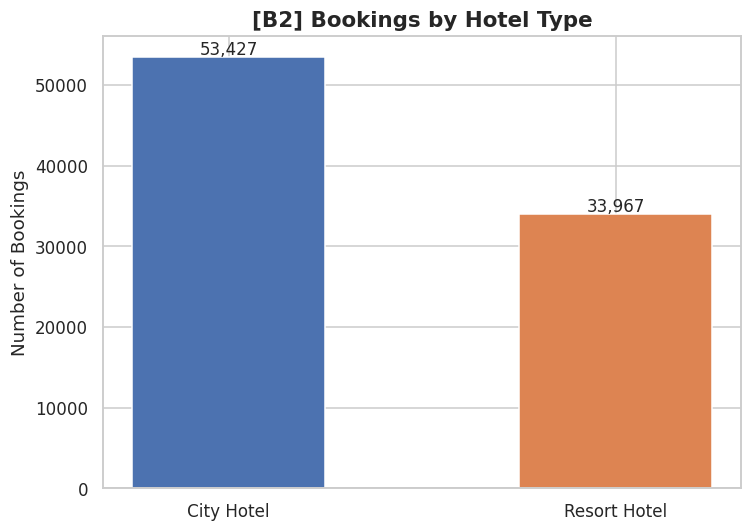

In [ ]:
#  Distribution of bookings by hotel type
hotel_counts = df["hotel"].value_counts()
print(f"\n[B2] Bookings by Hotel Type:")
print(hotel_counts.to_string())

plt.figure(figsize=(7, 5))
bars = plt.bar(hotel_counts.index, hotel_counts.values,
               color=["#4C72B0", "#DD8452"], edgecolor="white", width=0.5)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 300,
             f"{bar.get_height():,}", ha="center", fontsize=11)
plt.title("[B2] Bookings by Hotel Type", fontsize=14, fontweight="bold")
plt.ylabel("Number of Bookings")
plt.tight_layout()
plt.savefig("b2_hotel_type.png", bbox_inches="tight")
plt.show()

In [ ]:
#  How many bookings were canceled
total_canceled = df["is_canceled"].sum()
cancel_pct = df["is_canceled"].mean() * 100
print(f"\n[B3] Total Canceled Bookings : {total_canceled:,}")
print(f"     Cancellation Rate        : {cancel_pct:.1f}%")



[B3] Total Canceled Bookings : 24,024
     Cancellation Rate        : 27.5%



[B4] Most Common Arrival Month: August
arrival_date_month
January       4693
February      6098
March         7511
April         7908
May           8355
June          7765
July         10057
August       11257
September     6690
October       6934
November      4995
December      5131


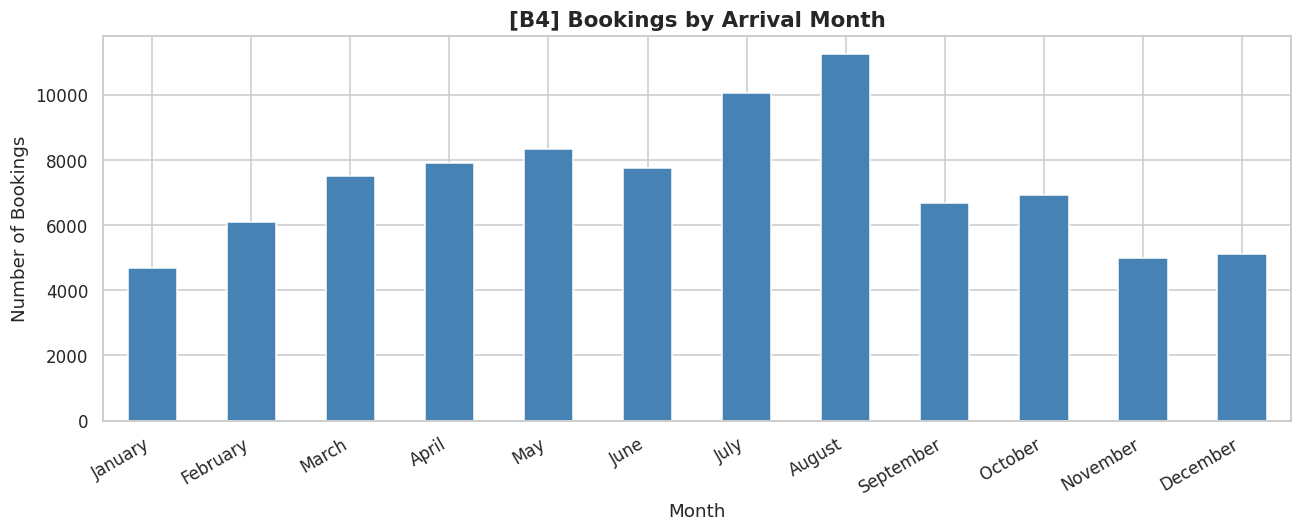

In [ ]:
#  Most common arrival month
most_common_month = df["arrival_date_month"].mode()[0]
month_counts = df["arrival_date_month"].value_counts().sort_index()
print(f"\n[B4] Most Common Arrival Month: {most_common_month}")
print(month_counts.to_string())

plt.figure(figsize=(12, 5))
month_counts.plot(kind="bar", color="steelblue", edgecolor="white")
plt.title("[B4] Bookings by Arrival Month", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("b4_arrival_month.png", bbox_inches="tight")
plt.show()


In [ ]:
#  Average special requests per booking
avg_special = df["total_of_special_requests"].mean()
print(f"\n[B5] Average Special Requests per Booking: {avg_special:.2f}")


[B5] Average Special Requests per Booking: 0.70


In [ ]:
#  Country with highest bookings
top_countries = df["country"].value_counts().head(10)
print(f"\n[B6] Top 10 Countries by Bookings:")
print(top_countries.to_string())


[B6] Top 10 Countries by Bookings:
country
PRT    27452
GBR    10432
FRA     8837
ESP     7252
DEU     5387
ITA     3066
IRL     3016
BEL     2081
BRA     1995
NLD     1911


In [ ]:
#  Average ADR for each hotel type
avg_adr_hotel = df.groupby("hotel")["adr"].mean()
print(f"\n[B7] Average ADR by Hotel Type:")
print(avg_adr_hotel.to_string())


[B7] Average ADR by Hotel Type:
hotel
City Hotel      110.886949
Resort Hotel     99.028449


In [ ]:
#  % Guests requiring car parking
parking_pct = (df["required_car_parking_spaces"] > 0).mean() * 100
print(f"\n[B8] Guests Requiring Car Parking: {parking_pct:.1f}%")



[B8] Guests Requiring Car Parking: 8.4%


In [ ]:
#  Average stay duration
avg_week  = df["stays_in_week_nights"].mean()
avg_wkend = df["stays_in_weekend_nights"].mean()
avg_total = df["total_stay"].mean()
print(f"\n[B9] Average Stay Duration:")
print(f"     Week Nights    : {avg_week:.2f}")
print(f"     Weekend Nights : {avg_wkend:.2f}")
print(f"     Total Nights   : {avg_total:.2f}")


[B9] Average Stay Duration:
     Week Nights    : 2.63
     Weekend Nights : 1.01
     Total Nights   : 3.63


In [ ]:
#  Bookings made through travel agents
agent_bookings = (df["agent"] > 0).sum()
agent_pct = (df["agent"] > 0).mean() * 100
print(f"\n[B10] Bookings via Travel Agents: {agent_bookings:,} ({agent_pct:.1f}%)")



[B10] Bookings via Travel Agents: 75,201 (86.0%)


MEDIUM-LEVEL QUESTIONS

In [ ]:
#  Cancellation rate by hotel type
cancel_by_hotel = df.groupby("hotel")["is_canceled"].mean() * 100
print(f"\n[M1] Cancellation Rate by Hotel Type (%):")
print(cancel_by_hotel.to_string())


[M1] Cancellation Rate by Hotel Type (%):
hotel
City Hotel      30.037247
Resort Hotel    23.481615



[M2] Average ADR by Market Segment:
market_segment
Online TA        118.171606
Direct           116.579429
Aviation         100.170396
Offline TA/TO     81.381254
Groups            74.880727
Corporate         68.151246
Undefined         15.000000
Complementary      3.049245


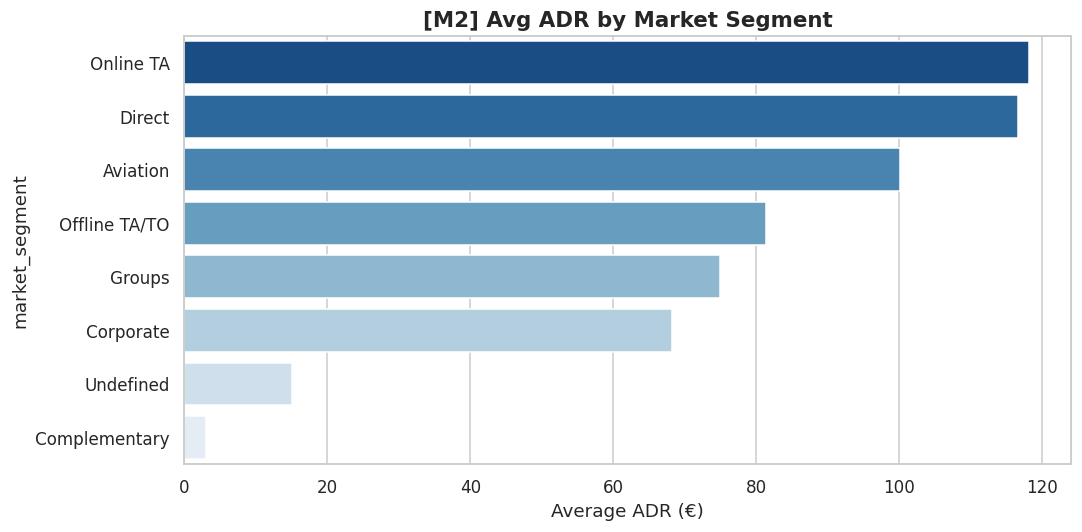

In [ ]:
#  Average ADR per market segment
adr_by_segment = (
    df.groupby("market_segment")["adr"]
    .mean()
    .sort_values(ascending=False)
)
print(f"\n[M2] Average ADR by Market Segment:")
print(adr_by_segment.to_string())

plt.figure(figsize=(10, 5))
sns.barplot(x=adr_by_segment.values, y=adr_by_segment.index, palette="Blues_r")
plt.title("[M2] Avg ADR by Market Segment", fontsize=14, fontweight="bold")
plt.xlabel("Average ADR (€)")
plt.tight_layout()
plt.savefig("m2_adr_segment.png", bbox_inches="tight")
plt.show()


[M3] Lead Time vs Cancellation Rate:
Lead Time (days)  Cancellation Rate (%)
            0-30              18.610898
           31-90              32.005452
          91-180              34.983281
         181-365              39.682114
            365+              41.030195


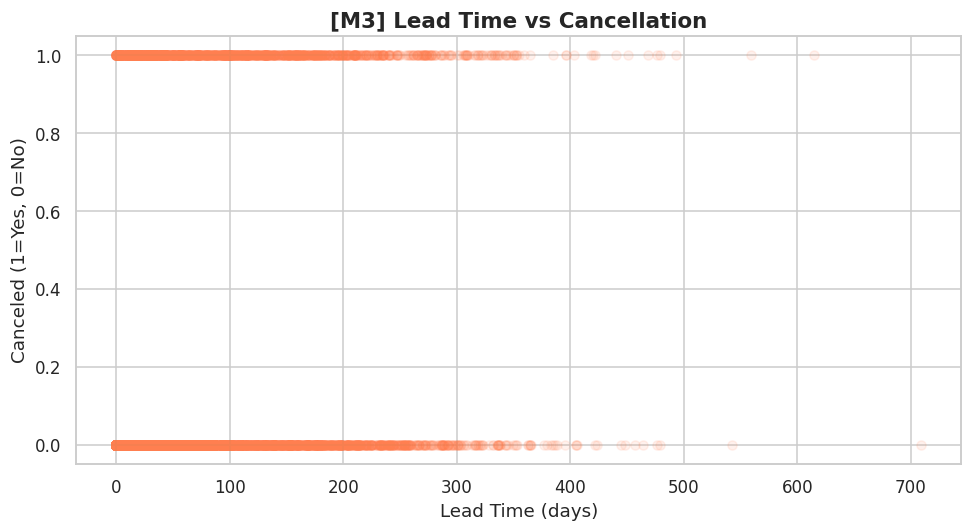

In [ ]:
#  Lead time vs Cancellation rate
# Bin lead time for clarity
df["lead_bin"] = pd.cut(df["lead_time"],
                         bins=[0, 30, 90, 180, 365, 700],
                         labels=["0-30", "31-90", "91-180", "181-365", "365+"])
lead_cancel = (
    df.groupby("lead_bin", observed=False)["is_canceled"]
    .mean() * 100
).reset_index()
lead_cancel.columns = ["Lead Time (days)", "Cancellation Rate (%)"]
print(f"\n[M3] Lead Time vs Cancellation Rate:")
print(lead_cancel.to_string(index=False))

plt.figure(figsize=(9, 5))
sample = df.sample(5000, random_state=42)
plt.scatter(sample["lead_time"], sample["is_canceled"],
            alpha=0.1, color="coral")
plt.title("[M3] Lead Time vs Cancellation", fontsize=14, fontweight="bold")
plt.xlabel("Lead Time (days)")
plt.ylabel("Canceled (1=Yes, 0=No)")
plt.tight_layout()
plt.savefig("m3_leadtime_cancel.png", bbox_inches="tight")
plt.show()

In [ ]:
#  Distribution channel with highest bookings
channel_counts = df["distribution_channel"].value_counts()
print(f"\n[M4] Bookings by Distribution Channel:")
print(channel_counts.to_string())



[M4] Bookings by Distribution Channel:
distribution_channel
TA/TO        69140
Direct       12987
Corporate     5081
GDS            181
Undefined        5


In [ ]:
#  Avg previous cancellations by hotel type
prev_cancel = df.groupby("hotel")["previous_cancellations"].mean()
print(f"\n[M5] Avg Previous Cancellations by Hotel Type:")
print(prev_cancel.to_string())



[M5] Avg Previous Cancellations by Hotel Type:
hotel
City Hotel      0.035768
Resort Hotel    0.021992



[M6] Average ADR by Year:
 arrival_date_year        adr
              2015  92.160752
              2016 101.413910
              2017 118.714608


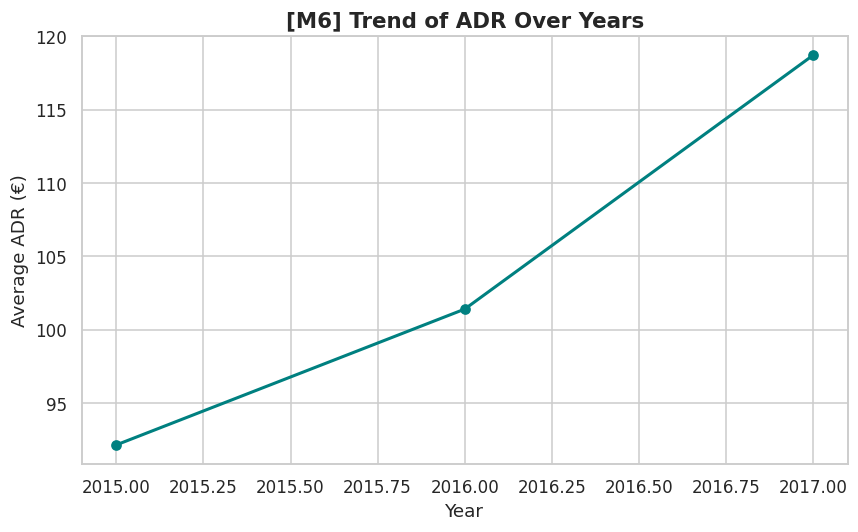

In [ ]:
# Trend of ADR over years
adr_year = df.groupby("arrival_date_year")["adr"].mean().reset_index()
print(f"\n[M6] Average ADR by Year:")
print(adr_year.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.plot(adr_year["arrival_date_year"], adr_year["adr"],
         marker="o", color="teal", linewidth=2)
plt.title("[M6] Trend of ADR Over Years", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Average ADR (€)")
plt.tight_layout()
plt.savefig("m6_adr_trend.png", bbox_inches="tight")
plt.show()


[M7] Total Revenue by Month:
arrival_date_month
January      1079597.52
February     1473600.20
March        2043349.13
April        2787157.05
May          3123058.22
June         3496345.05
July         5863024.99
August       7240652.99
September    2689186.19
October      2032649.25
November     1219278.35
December     1407704.17


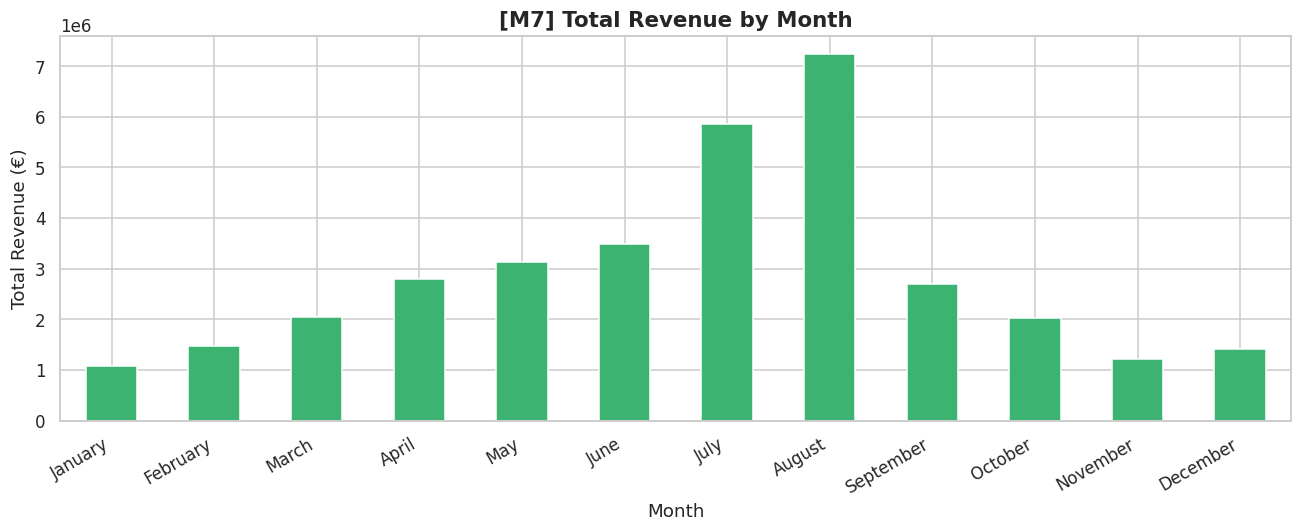

In [ ]:
# . Month with highest revenue
df["revenue"] = df["adr"] * df["total_stay"]
monthly_rev = (
    df.groupby("arrival_date_month")["revenue"]
    .sum()
    .sort_index()
)
print(f"\n[M7] Total Revenue by Month:")
print(monthly_rev.to_string())

plt.figure(figsize=(12, 5))
monthly_rev.plot(kind="bar", color="mediumseagreen", edgecolor="white")
plt.title("[M7] Total Revenue by Month", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Revenue (€)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("m7_monthly_revenue.png", bbox_inches="tight")
plt.show()

In [ ]:
# Impact of special requests on ADR
special_adr = df.groupby("total_of_special_requests")["adr"].mean()
print(f"\n[M8] Avg ADR by Number of Special Requests:")
print(special_adr.to_string())


[M8] Avg ADR by Number of Special Requests:
total_of_special_requests
0     99.547291
1    109.651497
2    118.570312
3    125.070790
4    131.088687
5    129.980000


In [ ]:
#  Avg stay duration: Repeated vs New guests
stay_by_guest = df.groupby("is_repeated_guest")["total_stay"].mean()
stay_by_guest.index = ["New Guest", "Repeated Guest"]
print(f"\n[M9] Average Stay Duration: Repeated vs New Guests:")
print(stay_by_guest.to_string())


[M9] Average Stay Duration: Repeated vs New Guests:
New Guest         3.699964
Repeated Guest    1.924722


In [ ]:
# Room type with highest bookings
room_counts = df["reserved_room_type"].value_counts()
print(f"\n[M10] Bookings by Reserved Room Type:")
print(room_counts.to_string())


[M10] Bookings by Reserved Room Type:
reserved_room_type
A    56550
D    17398
E     6049
F     2823
G     2052
B      999
C      915
H      596
L        6
P        6


ADVANCED-LEVEL QUESTIONS

In [ ]:
#  Factors impacting cancellation rate
# Correlation of numeric features with is_canceled
num_cols = ["lead_time", "booking_changes", "total_of_special_requests",
            "previous_cancellations", "days_in_waiting_list",
            "required_car_parking_spaces", "adr", "total_stay"]
corr_cancel = df[num_cols + ["is_canceled"]].corr()["is_canceled"].drop("is_canceled")
corr_cancel = corr_cancel.sort_values(key=abs, ascending=False)
print(f"\n[A1] Correlation of Features with Cancellation:")
print(corr_cancel.to_string())


[A1] Correlation of Features with Cancellation:
lead_time                      0.184830
required_car_parking_spaces   -0.184206
adr                            0.133456
total_of_special_requests     -0.120538
booking_changes               -0.093651
total_stay                     0.084140
previous_cancellations         0.051469
days_in_waiting_list           0.004465


In [ ]:
#  ADR vs Adults, Children, Babies
adr_adults   = df.groupby("adults")["adr"].mean().head(6)
adr_children = df.groupby("children")["adr"].mean().head(5)
print(f"\n[A2] Avg ADR by Number of Adults:")
print(adr_adults.to_string())
print(f"\n     Avg ADR by Number of Children:")
print(adr_children.to_string())



[A2] Avg ADR by Number of Adults:
adults
0     50.920831
1     80.344246
2    108.434752
3    157.909555
4    197.304167
5      0.000000

     Avg ADR by Number of Children:
children
0     100.731461
1     142.043463
2     179.610231
3     198.430133
10    133.160000


In [ ]:
#  Booking changes vs Special requests
corr_val = df["booking_changes"].corr(df["total_of_special_requests"])
print(f"\n[A3] Correlation — Booking Changes vs Special Requests: {corr_val:.4f}")

bc_sr = df.groupby("booking_changes")["total_of_special_requests"].mean().head(8)
print(f"\n     Avg Special Requests by Booking Changes:")
print(bc_sr.to_string())



[A3] Correlation — Booking Changes vs Special Requests: 0.0161

     Avg Special Requests by Booking Changes:
booking_changes
0    0.696562
1    0.682048
2    0.737382
3    0.826286
4    0.820225
5    0.836207
6    0.864407
7    0.645161



[A4] Cancellation Rate by Season (%):
season
Spring    28.097922
Summer    31.551979
Autumn    23.298781
Winter    24.061048


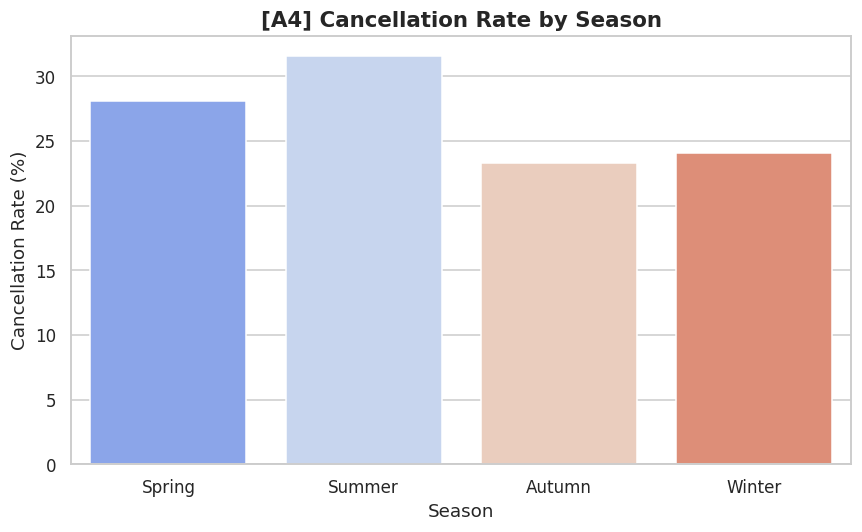

In [ ]:
#  Seasonal impact on cancellations
def get_season(month):
    if month in ["December", "January", "February"]:
        return "Winter"
    elif month in ["March", "April", "May"]:
        return "Spring"
    elif month in ["June", "July", "August"]:
        return "Summer"
    else:
        return "Autumn"

df["season"] = df["arrival_date_month"].astype(str).apply(get_season)
season_cancel = df.groupby("season")["is_canceled"].mean() * 100
season_cancel = season_cancel.reindex(["Spring", "Summer", "Autumn", "Winter"])
print(f"\n[A4] Cancellation Rate by Season (%):")
print(season_cancel.to_string())

plt.figure(figsize=(8, 5))
sns.barplot(x=season_cancel.index, y=season_cancel.values, palette="coolwarm")
plt.title("[A4] Cancellation Rate by Season", fontsize=14, fontweight="bold")
plt.xlabel("Season")
plt.ylabel("Cancellation Rate (%)")
plt.tight_layout()
plt.savefig("a4_seasonal_cancellation.png", bbox_inches="tight")
plt.show()


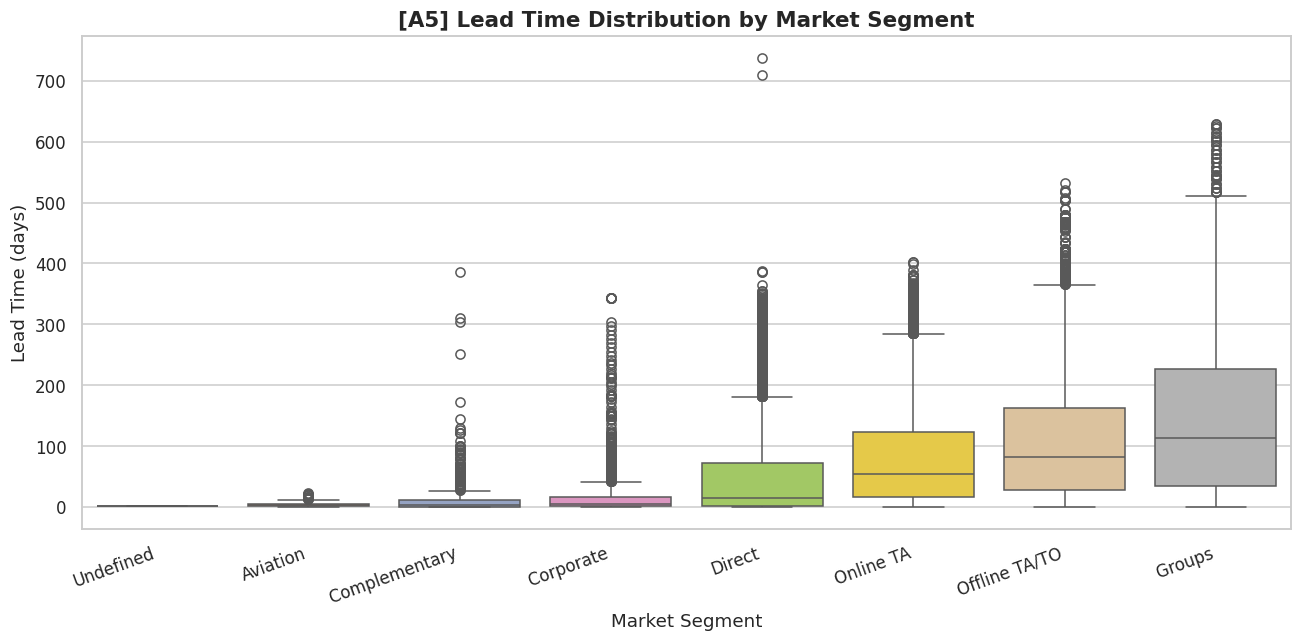


[A5] Boxplot saved → a5_leadtime_segment.png


In [ ]:
#  Lead time distribution by market segment
plt.figure(figsize=(12, 6))
seg_order = df.groupby("market_segment")["lead_time"].median().sort_values().index
sns.boxplot(data=df, x="market_segment", y="lead_time",
            order=seg_order, palette="Set2")
plt.title("[A5] Lead Time Distribution by Market Segment",
          fontsize=14, fontweight="bold")
plt.xlabel("Market Segment")
plt.ylabel("Lead Time (days)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("a5_leadtime_segment.png", bbox_inches="tight")
plt.show()
print("\n[A5] Boxplot saved → a5_leadtime_segment.png")


In [ ]:
#   FINAL SUMMARY

print("\n" + "=" * 55)
print(" KEY INSIGHTS SUMMARY")
print("=" * 55)
print(f"Total Bookings               : {df.shape[0]:,}")
print(f"Cancellation Rate            : {df['is_canceled'].mean()*100:.1f}%")
print(f"Avg Lead Time                : {df['lead_time'].mean():.1f} days")
print(f"Avg ADR                      : €{df['adr'].mean():.2f}")
print(f"Avg Total Stay               : {df['total_stay'].mean():.2f} nights")
print(f"Most Common Arrival Month    : {df['arrival_date_month'].mode()[0]}")
print(f"Top Booking Country          : {df['country'].value_counts().index[0]}")
print(f"Bookings via Travel Agents   : {agent_pct:.1f}%")
print(f"Guests Needing Parking       : {parking_pct:.1f}%")
print("=" * 55)



 KEY INSIGHTS SUMMARY
Total Bookings               : 87,394
Cancellation Rate            : 27.5%
Avg Lead Time                : 79.9 days
Avg ADR                      : €106.28
Avg Total Stay               : 3.63 nights
Most Common Arrival Month    : August
Top Booking Country          : PRT
Bookings via Travel Agents   : 86.0%
Guests Needing Parking       : 8.4%
